In [9]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
df = pd.read_csv('co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())

Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [10]:
print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))

Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


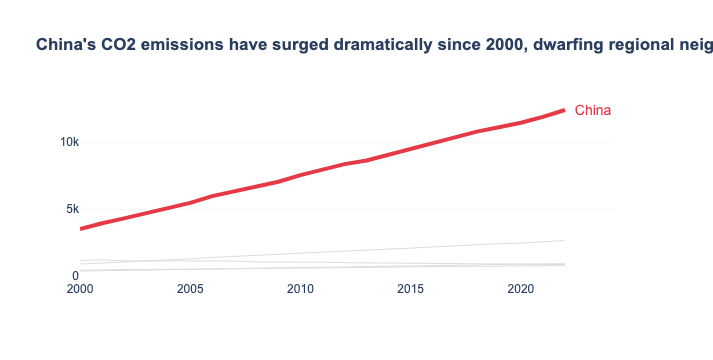

In [12]:
import plotly.graph_objects as go
df_asia = df[df['Region'] == 'Asia']
countries = df_asia['Country'].unique()
highlight_country = 'China' 


fig = go.Figure()

for country in countries:
    country_data = df_asia[df_asia['Country'] == country]
    is_target = (country == highlight_country)
    line_color = '#E63946' if is_target else '#DDDDDD'
    line_width = 4 if is_target else 1
    
    fig.add_trace(go.Scatter(
        x=country_data['Year'], 
        y=country_data['CO2_Mt'],
        mode='lines',
        name=country,
        line=dict(color=line_color, width=line_width),
        hoverinfo='name+y'
    ))


last_year = df_asia['Year'].max()
last_val = df_asia[(df_asia['Country'] == highlight_country) & (df_asia['Year'] == last_year)]['CO2_Mt'].iloc[0]

fig.add_annotation(
    x=last_year, y=last_val, text=f"  {highlight_country}",
    showarrow=False, xanchor="left", font=dict(color='#E63946', size=14, family="Arial")
)


fig.update_layout(
    title="<b>China's CO2 emissions have surged dramatically since 2000, dwarfing regional neighbors</b>",
    plot_bgcolor='white', showlegend=False,
    font=dict(family="Arial", size=12),
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=True, gridcolor='#F5F5F5'),
    margin=dict(r=100)
)
fig.show()

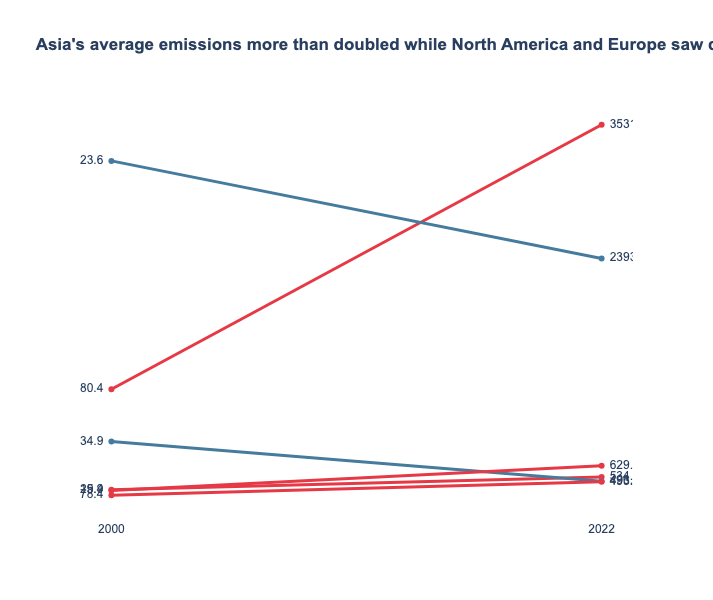

In [13]:
df_slope = (df[df['Year'].isin([2000, 2022])]
            .groupby(['Region', 'Year'])['CO2_Mt']
            .mean()
            .reset_index())

fig = go.Figure()

for region in df_slope['Region'].unique():
    region_data = df_slope[df_slope['Region'] == region]
    
    val_2000 = region_data[region_data['Year'] == 2000]['CO2_Mt'].values[0]
    val_2022 = region_data[region_data['Year'] == 2022]['CO2_Mt'].values[0]
    line_color = "#E63946" if val_2022 > val_2000 else "#457B9D"
    
    fig.add_trace(go.Scatter(
        x=region_data['Year'], 
        y=region_data['CO2_Mt'],
        mode='lines+markers+text',
        name=region,
        line=dict(color=line_color, width=3),
        text=[f"{region} {val_2000:.1f} ", f" {val_2022:.1f}"],
        textposition=["middle left", "middle right"],
        hoverinfo='none'
    ))


fig.update_layout(
    title="<b>Asia's average emissions more than doubled while North America and Europe saw declines</b>",
    xaxis=dict(type='category', showgrid=False, zeroline=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    plot_bgcolor='white', showlegend=False,
    font=dict(family="Arial"), height=600
)
fig.show()